#  IN3050/IN4050 Mandatory Assignment 1: Traveling Salesman Problem


In [ ]:
#My Name is Zejing Wang
#Username zejingw

#How to run the code?

#In the notebook, press "Run all"

## Rules
Before you begin the exercise, review the rules at this website: https://www.uio.no/english/studies/examinations/compulsory-activities/mn-ifi-mandatory.html, in particular the paragraph on cooperation. This is an individual assignment. You are not allowed to deliver together or copy/share source code/answers with others. Read also the "Routines for handling suspicion of cheating and attempted cheating at the University of Oslo": https://www.uio.no/english/studies/examinations/cheating/index.html. By submitting this assignment, you confirm that you are familiar with the rules and the consequences of breaking them.

### Delivery

**Deadline**: October 6 2026, 23:59

Your submission should be delivered in Devilry. You may redeliver in Devilry before the deadline, but include all files in the last delivery, as only the last delivery will be read. You are recommended to upload preliminary versions hours (or days) before the final deadline.

## What to deliver?

Deliver one single zipped folder (.zip, .tgz or .tar.gz) which includes:
* PDF report containing:
    * Your name and username (!)
    * Instructions on how to run your program, with example runs.
    * Answers to all questions from assignment.
    * Brief explanation of what you’ve done.
    * *Your PDF may be generated by exporting your Jupyter Notebook to PDF, if you have answered all questions in your notebook*
* Source code
    * Source code may be delivered as jupyter notebooks or python files (.py)
* The european cities file so the program will run right away.
* Any files needed for the group teacher to easily run your program on IFI linux machines.

**Important**: 
* Include example runs of your code by doing the reports described in the tasks. Simply implementing the code, but never running it will not give many points.
* Include the code that was used to make all reports. Do not include reports of performance and time without also including the code that was used to produce it.
* If you weren’t able to finish the assignment, use the PDF report to elaborate on what you’ve tried
and what problems you encountered. Students who have made an effort and attempted all parts of the assignment
will get a second chance even if they fail initially. This exercise will be graded PASS/FAIL.

## Introduction
In this exercise, you will attempt to solve an instance of the traveling salesman problem (TSP) using different
methods. The goal is to become familiar with evolutionary algorithms and to appreciate their effectiveness on a
difficult search problem. You have to use Python to solve the assignment. You must write
your program from scratch (but you may use non-EA-related libraries).


|  &nbsp;   | Barcelona | Belgrade |  Berlin | Brussels | Bucharest | Budapest |
|:---------:|:---------:|:--------:|:-------:|:--------:|:---------:|:--------:|
| Barcelona |     0     |  1528.13 | 1497.61 |  1062.89 |  1968.42  |  1498.79 |
|  Belgrade |  1528.13  |     0    |  999.25 |  1372.59 |   447.34  |  316.41  |
|   Berlin  |  1497.61  |  999.25  |    0    |  651.62  |  1293.40  |  1293.40 |
|  Brussels |  1062.89  |  1372.59 |  651.62 |     0    |  1769.69  |  1131.52 |
| Bucharest |  1968.42  |  447.34  | 1293.40 |  1769.69 |     0     |  639.77  |
|  Budapest |  1498.79  |  316.41  | 1293.40 |  1131.52 |   639.77  |     0    |


<center>Figure 1: First 6 cities from csv file.</center>


## Problem
The traveling salesman, wishing to disturb the residents of the major cities in some region of the world in
the shortest time possible, is faced with the problem of finding the shortest tour among the cities. A tour
is a path that starts in one city, visits all of the other cities, and then returns to the starting point. The
relevant pieces of information, then, are the cities and the distances between them. In this instance of the
TSP, a number of European cities are to be visited. Their relative distances are given in the data file, *european_cities.csv*, found in the zip file with the mandatory assignment.

(You will use permutations to represent tours in your programs. The **itertools** module in Python provides
a permutations function that returns successive permutations, this is useful for exhaustive search)

## Helper code for visualizing solutions

Here follows some helper code that you can use to visualize the plans you generate. These visualizations can **help you check if you are making sensible tours or not**. The optimization algoritms below should hopefully find relatively nice looking tours, but perhaps with a few visible inefficiencies.

In [49]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
np.random.seed(57)
#Map of Europe
europe_map = plt.imread('map.png')

#Lists of city coordinates
city_coords = {
    "Barcelona": [2.154007, 41.390205], "Belgrade": [20.46, 44.79], "Berlin": [13.40, 52.52], 
    "Brussels": [4.35, 50.85], "Bucharest": [26.10, 44.44], "Budapest": [19.04, 47.50],
    "Copenhagen": [12.57, 55.68], "Dublin": [-6.27, 53.35], "Hamburg": [9.99, 53.55], 
    "Istanbul": [28.98, 41.02], "Kyiv": [30.52, 50.45], "London": [-0.12, 51.51], 
    "Madrid": [-3.70, 40.42], "Milan": [9.19, 45.46], "Moscow": [37.62, 55.75],
    "Munich": [11.58, 48.14], "Paris": [2.35, 48.86], "Prague": [14.42, 50.07],
    "Rome": [12.50, 41.90], "Saint Petersburg": [30.31, 59.94], "Sofia": [23.32, 42.70],
    "Stockholm": [18.06, 60.33], "Vienna": [16.36, 48.21], "Warsaw": [21.02, 52.24]}


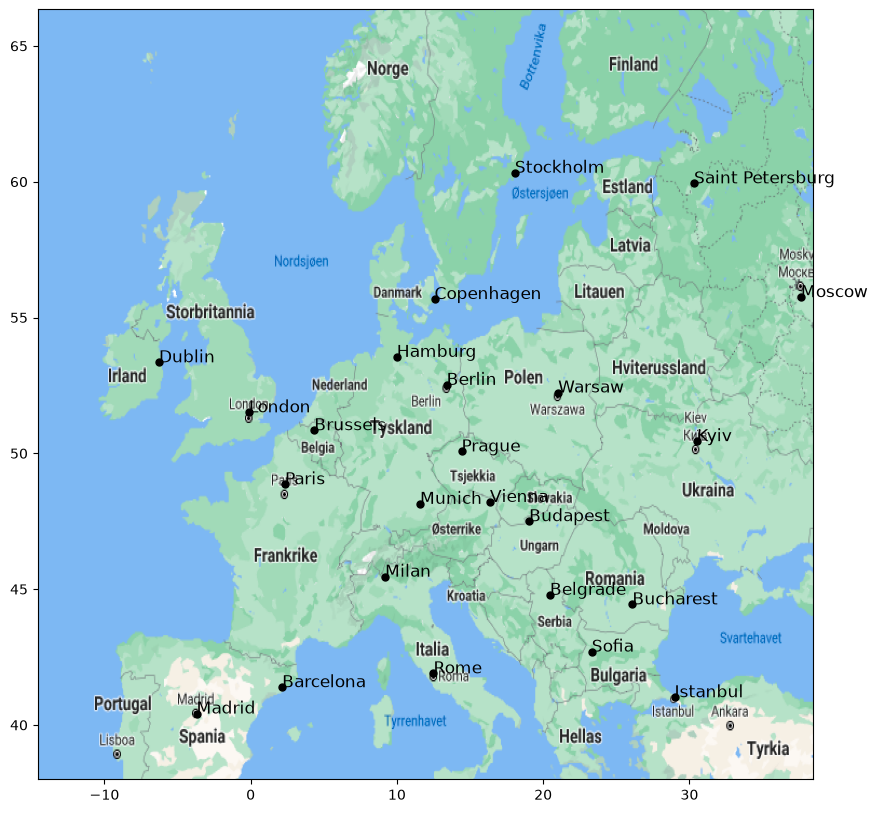

In [23]:
#Helper code for plotting plans
#First, visualizing the cities.
import csv
with open("european_cities.csv", "r") as f:
    data = list(csv.reader(f, delimiter=';'))
    cities = data[0]

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(europe_map, extent=[-14.56, 38.43, 37.697 + 0.3, 64.344 + 2.0], aspect="auto")

# Map (long, lat) to (x, y) for plotting
for city, location in city_coords.items():
    x, y = (location[0], location[1])
    plt.plot(x, y, 'ok', markersize=5)
    plt.text(x, y, city, fontsize=12)


In [24]:
#A method you can use to plot your plan on the map.
def plot_plan(city_order):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(europe_map, extent=[-14.56, 38.43, 37.697 + 0.3, 64.344 + 2.0], aspect="auto")

    # Map (long, lat) to (x, y) for plotting
    for index in range(len(city_order) - 1):
        current_city_coords = city_coords[city_order[index]]
        next_city_coords = city_coords[city_order[index+1]]
        x, y = current_city_coords[0], current_city_coords[1]
        #Plotting a line to the next city
        next_x, next_y = next_city_coords[0], next_city_coords[1]
        plt.plot([x, next_x], [y, next_y])

        plt.plot(x, y, 'ok', markersize=5)
        plt.text(x, y, index, fontsize=12)
    #Finally, plotting from last to first city
    first_city_coords = city_coords[city_order[0]]
    first_x, first_y = first_city_coords[0], first_city_coords[1]
    plt.plot([next_x, first_x], [next_y, first_y])
    #Plotting a marker and index for the final city
    plt.plot(next_x, next_y, 'ok', markersize=5)
    plt.text(next_x, next_y, index+1, fontsize=12)
    plt.show()


['Barcelona', 'Belgrade', 'Berlin', 'Brussels', 'Bucharest', 'Budapest', 'Copenhagen', 'Dublin', 'Hamburg', 'Istanbul', 'Kyiv', 'London', 'Madrid', 'Milan', 'Moscow', 'Munich', 'Paris', 'Prague', 'Rome', 'Saint Petersburg', 'Sofia', 'Stockholm', 'Vienna', 'Warsaw']


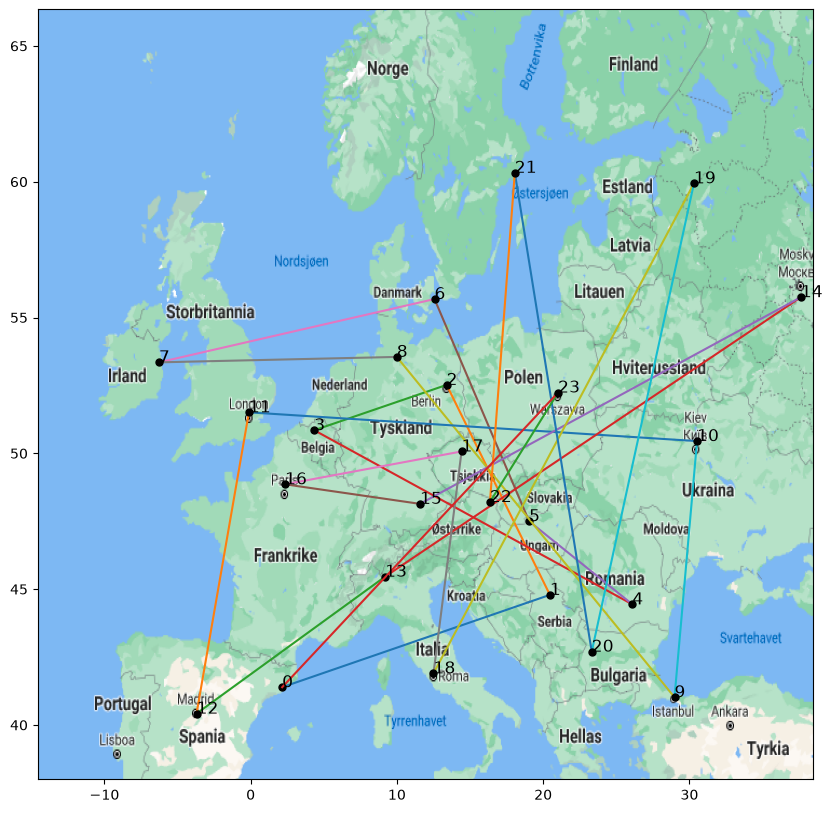

In [25]:
#Example usage of the plotting-method.
plan = list(city_coords.keys()) # Gives us the cities in alphabetic order
print(plan)
plot_plan(plan)

## Working with the lecture notebooks

The tasks below are versions of exercises you have already met in the weekly notebooks. Each task points to the lecture that covers it, and the code cells give you the function signatures similar to those in the weekly notebooks. You can find inspiration for how to use the functions to solve the assignment tasks in those notebooks. The signatures are a starting point, not a requirement: change them if you prefer a different structure, but say so in your report.

## Exhaustive Search
First, try to solve the problem by inspecting every possible tour. Start by writing a program to find the shortest
tour among a subset of the cities (say, **6** of them). Measure the amount of time your program takes. Incrementally
add more cities and observe how the time increases. Plot the shortest tours you found using the plot_plan method above, for 6 and 10 cities.

**Note:** To get distances between cities, use the dictionary `data` created by reading the file `european_cities.csv`. *Do not* calculate distances based on the coordinates. The actual distances do not only depend on the differences in the coordinates, but also of the curvature of the earth. The distances available in `data` are corrected for this, and contain the actual true distances.

**Hint:** You may build your solution inspired by what is shown in the weekly notebook for Lecture 2.

In [26]:
def tour_length(city_order):
    # See Lecture 2's tour_length. There the distance between two cities is
    # computed from their coordinates; here, index the distance matrix instead.
    total_length = 0.0
    #My own code.
    for i in range(len(city_order)):
        current_city = city_order[i]
        next_city = city_order[(i + 1) % len(city_order)]

        total_length += float(data[current_city + 1][next_city])

    return total_length
import itertools

def exhaustive_search(n_cities):
    # See Exercise 2 in the Lecture 2 practice notebook for inspiration.
    # Fix city 0 as the start to avoid counting the same cycle from every possible start.
    best_order = None
    best_length = float("inf")
    
    for rest in itertools.permutations(range(1, n_cities)):
        candidate = (0,) + rest

        length = tour_length(candidate)

        if length < best_length:
            best_length = length
            best_order = candidate

    return best_order, best_length


print(exhaustive_search(6))

# Conclusion
# For the first 6 cities, exhaustive search found the optimal tour
# (0, 1, 4, 5, 2, 3) with a total length of 5018.8099999999995
# Since all possible tours were checked, this is the global optimum.



((0, 1, 4, 5, 2, 3), 5018.8099999999995)


What is the shortest tour (i.e., the actual sequence of cities, and its length) among the first 10 cities (that is,
the cities starting with B,C,D,H and I)? How long did your program take to find it? Calculate an approximation of how long it would take to perform exhaustive search on all 24 cities?

Best tour: ['Barcelona', 'Belgrade', 'Istanbul', 'Bucharest', 'Budapest', 'Berlin', 'Copenhagen', 'Hamburg', 'Brussels', 'Dublin']
Best order: (0, 1, 9, 4, 5, 2, 6, 8, 3, 7)
Tour length: 7486.3099999999995
Running time: 0.593574299942702 seconds
Estimated time for 24 cities: 1339992962.3916924 years
6 cities: best length = 5018.81, time = 0.000136 seconds
7 cities: best length = 5487.89, time = 0.000859 seconds
8 cities: best length = 6667.49, time = 0.006693 seconds
9 cities: best length = 6678.55, time = 0.059827 seconds
10 cities: best length = 7486.31, time = 0.579881 seconds


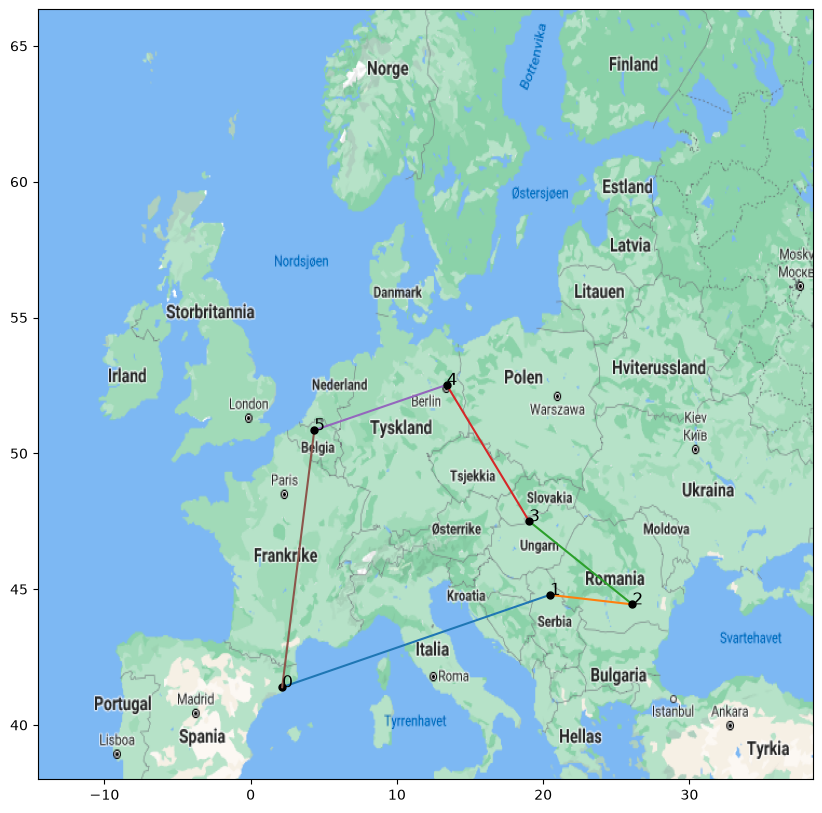

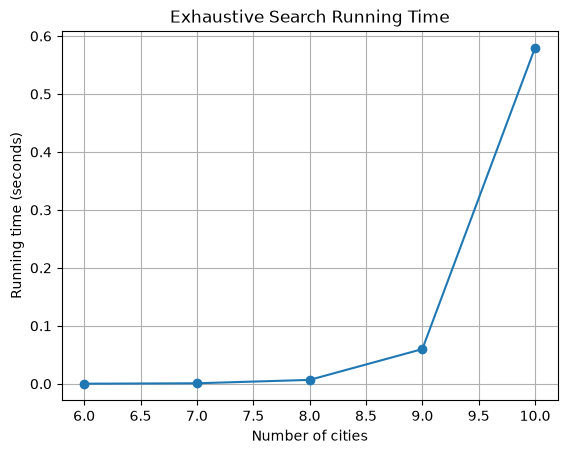

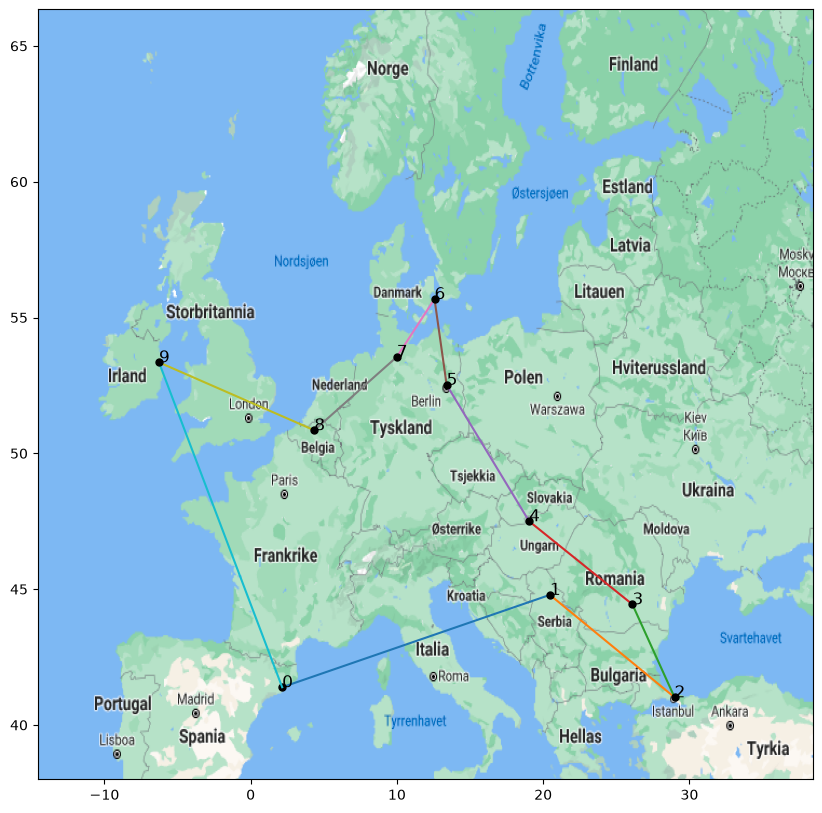

In [60]:
import time
import math

# Run exhaustive search for the first 10 cities
start_time = time.perf_counter()
best_order_10, best_length_10 = exhaustive_search(10)
end_time = time.perf_counter()
time_10 = end_time - start_time

# Convert city indices to city names
best_cities_10 = [cities[i] for i in best_order_10]
print("Best tour:", best_cities_10)
print("Best order:", best_order_10)
print("Tour length:", best_length_10)
print("Running time:", time_10, "seconds")


# Estimate exhaustive search time for 24 cities
# City 0 is fixed, so:
# 10 cities -> 9! possible tours
# 24 cities -> 23! possible tours
estimated_time_24 = time_10 * math.factorial(23) / math.factorial(9)
seconds_per_year = 60 * 60 * 24 * 365.25
estimated_years_24 = estimated_time_24 / seconds_per_year
print("Estimated time for 24 cities:", estimated_years_24, "years")

city_numbers = []
running_times = []

for n in range(6, 11):
    start_time = time.perf_counter()
    best_order, best_length = exhaustive_search(n)
    end_time = time.perf_counter()
    running_time = end_time - start_time
    city_numbers.append(n)
    running_times.append(running_time)
    print( f"{n} cities: " f"best length = {best_length:.2f}, " f"time = {running_time:.6f} seconds" )

best_order_6, best_length_6 = exhaustive_search(6)
best_cities_6 = [cities[i] for i in best_order_6]

plot_plan(best_cities_6)
plt.plot(city_numbers, running_times, marker="o")
plt.xlabel("Number of cities")
plt.ylabel("Running time (seconds)")
plt.title("Exhaustive Search Running Time")
plt.grid()
plt.show()
plot_plan(best_cities_10)

# Conclusion
# The shortest tour for the first 10 cities has a length of 7486.31.
# The exhaustive search took about 0.59 seconds.
# The running time increases rapidly because the number of possible tours grows factorially.
# For 24 cities, the estimated running time is about 1.33 billion years,
# which makes exhaustive search impractical.

## Hill Climbing
Then, write a simple hill climber to solve the TSP. How well does the hill climber perform, compared to the result from the exhaustive search for the first **10 cities**? Since you are dealing with a stochastic algorithm, you
should run the algorithm several times to measure its performance. Report the length of the tour of the best,
worst and mean of 20 runs (with random starting tours), as well as the standard deviation of the runs, both with the **10 first cities**, and with all **24 cities**. Plot one of the the plans from the 20 runs for both 10 cities and 24 cities (you can use plot_plan).

**Hint:** You can build your solution inspired by what is shown in the Lecture 2 weekly notebooks. The lecture notebook climbs a one-dimensional numerical function, where the neighbors of `x` are `x - step` and `x + step`. In TSP, a possible solution is any permutation of the cities to visit, so the part you have to decide is what counts as a neighboring solution to a given permutation (there is not just one correct solution to this!).

10 cities:
Best: 7486.3099999999995
Worst: 8391.05
Mean: 7864.275
Standard deviation: 394.85540081781807
Best run for 10 cities: 7
Best length: 7486.3099999999995
Best order: [0 1 9 4 5 2 6 8 3 7]
Best city order: ['Barcelona', 'Belgrade', 'Istanbul', 'Bucharest', 'Budapest', 'Berlin', 'Copenhagen', 'Hamburg', 'Brussels', 'Dublin']


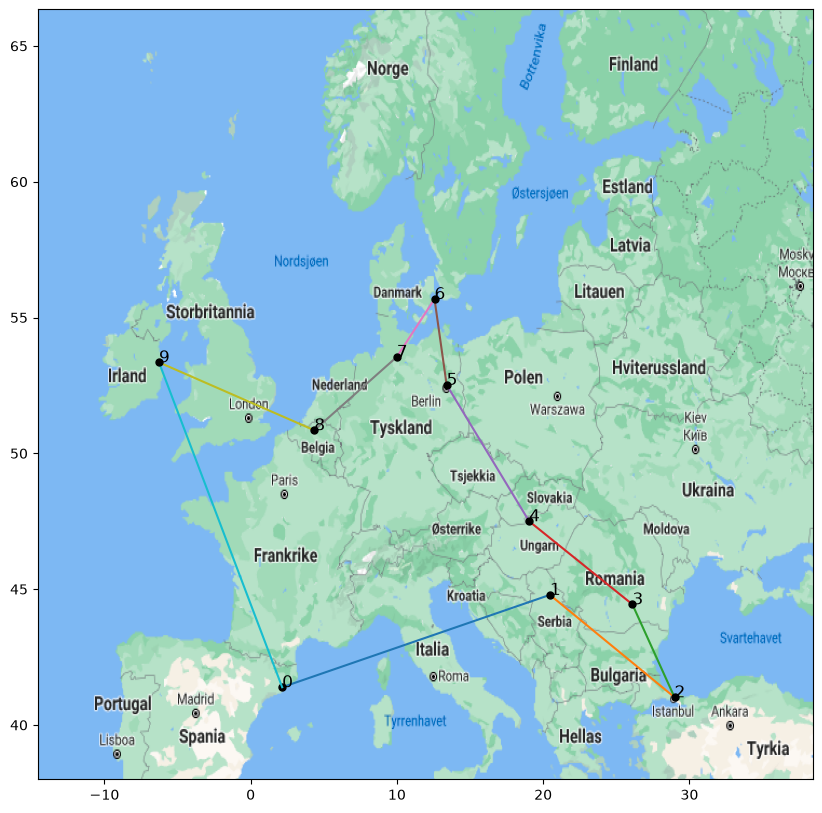

24 cities:
Best: 12737.73
Worst: 18013.05
Mean: 14521.328
Standard deviation: 1399.8835900552592
Best run for 24 cities: 16
Best length: 12737.73
Best order: [ 0 13 18  5  1 20  9  4 10 14 19 21  6  8  2 23 22 17 15  3 16 11  7 12]
Best city order: ['Barcelona', 'Milan', 'Rome', 'Budapest', 'Belgrade', 'Sofia', 'Istanbul', 'Bucharest', 'Kyiv', 'Moscow', 'Saint Petersburg', 'Stockholm', 'Copenhagen', 'Hamburg', 'Berlin', 'Warsaw', 'Vienna', 'Prague', 'Munich', 'Brussels', 'Paris', 'London', 'Dublin', 'Madrid']


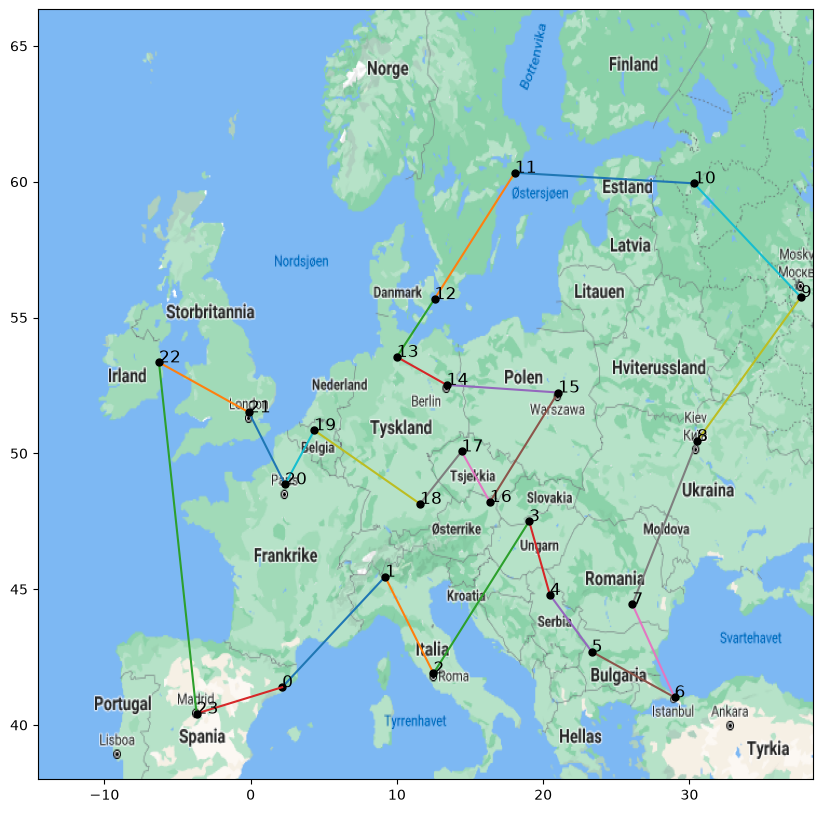

In [58]:
def hill_climb(start_order, n_cities, max_steps):

    # See Lecture 2's implementation of hill climbing for inspiration.

    best_order = np.array(start_order).copy()
    best_length = tour_length(best_order)

    for _ in range(max_steps):

        candidates = []

        for i in range(1, n_cities): #Keep city 0 fixed and swap two other cities
            for j in range(i + 1, n_cities):

                candidate = best_order.copy()
                candidate[i], candidate[j] = candidate[j], candidate[i]
                candidates.append(candidate)

        candidate_lengths = [tour_length(candidate) for candidate in candidates]

        best_index = np.argmin(candidate_lengths)
        new_order = candidates[best_index]
        new_length = candidate_lengths[best_index]

        if new_length < best_length: #Use the new tour if it is better
            best_order = new_order
            best_length = new_length
        else:
            break

    return best_order, best_length


def report_runs(lengths):

    print("Best:", np.min(lengths))
    print("Worst:", np.max(lengths))
    print("Mean:", np.mean(lengths))
    print("Standard deviation:", np.std(lengths))


#Run the hill climbing algorithm 20 times for 10 cities
np.random.seed(57)
n_runs = 20
n_cities = 10
lengths_10 = []
orders_10 = []

for _ in range(n_runs):

    start_order = np.concatenate(([0], np.random.permutation(np.arange(1, n_cities))))
    best_order, best_length = hill_climb(start_order, n_cities, max_steps=100)

    lengths_10.append(best_length)
    orders_10.append(best_order.copy())
print("10 cities:")
report_runs(lengths_10)
best_run_10 = np.argmin(lengths_10)
print("Best run for 10 cities:", best_run_10)
print("Best length:", lengths_10[best_run_10])
print("Best order:", orders_10[best_run_10])


#Plot the best plan for 10 cities

best_cities_10 = [cities[i] for i in orders_10[best_run_10]]
print("Best city order:", best_cities_10)
plot_plan(best_cities_10)


#Run the hill climbing algorithm 20 times for 24 cities
n_cities = 24
lengths_24 = []
orders_24 = []
for _ in range(n_runs):
    start_order = np.concatenate(([0], np.random.permutation(np.arange(1, n_cities))))
    best_order, best_length = hill_climb(start_order, n_cities, max_steps=100)
    lengths_24.append(best_length)
    orders_24.append(best_order.copy())

print("24 cities:")
report_runs(lengths_24)
best_run_24 = np.argmin(lengths_24)
print("Best run for 24 cities:", best_run_24)
print("Best length:", lengths_24[best_run_24])
print("Best order:", orders_24[best_run_24])


# Plot the best plan for 24 cities
best_cities_24 = [cities[i] for i in orders_24[best_run_24]]
print("Best city order:", best_cities_24)
plot_plan(best_cities_24)

#Conclusion

#For 10 cities, the best tour length was 7486.3099999999995
#the worst was 8391.05 , and the mean was 7864.275 with a standard deviation of 394.85540081781807
#The best result is the same as the exhaustive search optimum, 
#so hill climbing found the global optimum in at least one run.

#For 24 cities, the best tour length was 12737.73 
#the worst was 18013.05, and the mean was 14521.328 with a standard deviation of 1399.8835900552592. 
#The larger variation shows that the result depends more on the random starting tour.


## Genetic Algorithm
Next, write a genetic algorithm (GA) to solve the problem. Choose mutation and crossover operators that are appropriate for the problem (see chapter 4.5 of Eiben and Smith). Choose three different values for the population size. Define and tune other parameters yourself and make assumptions as necessary (and report them, of course).

For all three variants: As with the hill climber, report best, worst, mean and standard deviation of tour length out of 20 runs of the algorithm (of the best individual of last generation). Also, find and plot the average fitness of the best fit individual in each generation (average across runs), and include a figure with all three curves in the same plot in the report. This means that the x-axis should be the generations over time and the y-axis should be the average (over the 20-runs) fitness of the best gene in that generation. Conclude which is best in terms of tour length and number of generations of evolution time.

Finally, plot an example optimized tour (the best of the final generation) for the three different population sizes, using the plot_plan method.

**Hint:** You may build your solution inspired by what is shown in the weekly notebooks for evolutionary algorithms. The practice notebook builds a complete evolutionary algorithm step by step, ending with the full execution loop, and the functions below follow its structure. 

Sections 9 to 11 of the Lecture 5 practice notebook show an example how to record the best fitness in each generation and how to compare repeated runs, which you need for the report.

In [ ]:
def evaluate_population(population):
    # See the Lecture 5 notebook's evaluate_population for a code example.
    fitness = []

    for individual in population:
        length = tour_length(individual)
        fitness.append(1.0 / length)

    return np.array(fitness)


def parent_selection(population, fitness, rng, tournament_size):
    #Select and implement an appropriate parent selection operator.
    #Pick some random individuals and choose the best one
    competitors = rng.choice(len(population), size=tournament_size, replace=False)
    winner = competitors[np.argmax(fitness[competitors])]
    return population[winner].copy()


def crossover(parent_a, parent_b, rng):
    #Select and implement an appropriate crossover operator.
    #Make a new child from the two parents
    n = len(parent_a)
    child = np.full(n, -1, dtype=int)

    # Keep city 0 fixed
    child[0] = 0
    #Choose two random cut points
    cut1, cut2 = sorted(rng.choice(np.arange(1, n), size=2, replace=False))

    #Copy part of parent A
    child[cut1:cut2 + 1] = parent_a[cut1:cut2 + 1]

    #Find the empty positions
    positions = list(range(cut2 + 1, n)) + list(range(1, cut1))

    #Parent b
    genes = list(parent_b[cut2 + 1:]) + list(parent_b[1:cut2 + 1])

    remaining = [gene for gene in genes if gene not in child]

    for position, gene in zip(positions, remaining):
        child[position] = gene

    return child


def mutation(individual, rng):
    # Select and implement an appropriate mutation operator.
    # Hint: see chapter 4.5 of Eiben and Smith.
    # See the Lecture 5 notebook's bit_flip_mutation for a code example for binary representations.
    child = individual.copy()
    mutation_rate = 0.2
    #Sometimes swap two cities
    if rng.random() < mutation_rate:
        i, j = rng.choice(np.arange(1, len(child)), size=2, replace=False)
        child[i], child[j] = child[j], child[i]

    return child


def survivor_selection(population, fitness, offspring):
    # Select and implement an appropriate survivor selection operator.
    # See the Lecture 5 notebook's make_next_population_task for a code example.

    #Put the old population and new children together
    combined_population = np.vstack((population, offspring))
    combined_fitness = evaluate_population(combined_population)
    population_size = len(population)
    best_indices = np.argsort(combined_fitness)[-population_size:] #Keep the best individuals

    return combined_population[best_indices]


def run_evolutionary_algorithm(n_cities, population_size, generations, seed):
    # Implement running one full generation of the EA algorithm,
    # using the above components.
    rng = np.random.default_rng(seed)

    population = []

    for _ in range(population_size):
        individual = np.concatenate(([0], rng.permutation(np.arange(1, n_cities))))
        population.append(individual)

    population = np.array(population)
    best_fitness_history = []

    #Run the generations
    for _ in range(generations):
        fitness = evaluate_population(population)
        offspring = []

        while len(offspring) < population_size:
            parent_a = parent_selection(population, fitness, rng, tournament_size=3)
            parent_b = parent_selection(population, fitness, rng, tournament_size=3)

            child = crossover(parent_a, parent_b, rng)
            child = mutation(child, rng)
            offspring.append(child)

        offspring = np.array(offspring)
        population = survivor_selection(population, fitness, offspring)

        fitness = evaluate_population(population)
        best_fitness_history.append(np.max(fitness))

    #Get the best tour at the end
    fitness = evaluate_population(population)
    best_index = np.argmax(fitness)
    best_order = population[best_index].copy()
    best_length = tour_length(best_order)

    return best_order, best_length, np.array(best_fitness_history)

Among the first 10 cities, did your GA find the shortest tour (as found by the exhaustive search)? Did it come close? 

For both 10 and 24 cities: How did the running time of your GA compare to that of the exhaustive search? 

How many tours were inspected by your GA as compared to by the exhaustive search?

Best: 13586.789999999997
Worst: 16246.519999999999
Mean: 15079.544499999998
Standard deviation: 756.6250122516108
Population size = 50
Best: 12325.93
Worst: 15482.119999999999
Mean: 14142.932
Standard deviation: 736.0383811432666
Population size = 100
Best: 12384.219999999996
Worst: 15691.04
Mean: 14116.127499999999
Standard deviation: 811.4765633514934
Population size = 20
Best: 13586.789999999997
Worst: 16246.519999999999
Mean: 15079.544499999998
Standard deviation: 756.6250122516108

Population size = 50
Best: 12325.93
Worst: 15482.119999999999
Mean: 14142.932
Standard deviation: 736.0383811432666

Population size = 100
Best: 12384.219999999996
Worst: 15691.04
Mean: 14116.127499999999
Standard deviation: 811.4765633514934


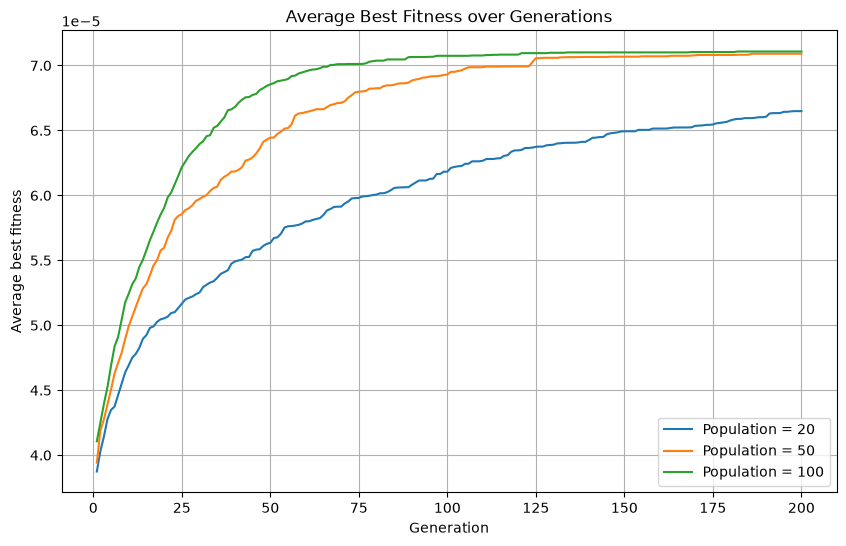

In [ ]:
# Answer

#Parameters 
n_runs = 20
n_cities = 24
population_size = 20
generations = 200
lengths_20 = []
orders_20 = []
histories_20 = []

for run in range(n_runs):
    best_order, best_length, best_fitness_history = run_evolutionary_algorithm(n_cities, population_size, generations, seed=run)
    lengths_20.append(best_length)
    orders_20.append(best_order.copy())
    histories_20.append(best_fitness_history)
report_runs(lengths_20)


# Population size = 50

population_size = 50
lengths_50 = []
orders_50 = []
histories_50 = []

for run in range(n_runs):
    best_order, best_length, best_fitness_history = run_evolutionary_algorithm( n_cities, population_size, generations, seed=run )
    lengths_50.append(best_length)
    orders_50.append(best_order.copy())
    histories_50.append(best_fitness_history)
print("Population size = 50")
report_runs(lengths_50)

# Population size = 100

population_size = 100
lengths_100 = []
orders_100 = []
histories_100 = []

for run in range(n_runs):
    best_order, best_length, best_fitness_history = run_evolutionary_algorithm( n_cities, population_size, generations, seed=run )
    lengths_100.append(best_length)
    orders_100.append(best_order.copy())
    histories_100.append(best_fitness_history)
print("Population size = 100")
report_runs(lengths_100)

histories_20 = np.array(histories_20)
histories_50 = np.array(histories_50)
histories_100 = np.array(histories_100)
average_fitness_20 = np.mean(histories_20, axis=0)
average_fitness_50 = np.mean(histories_50, axis=0)
average_fitness_100 = np.mean(histories_100, axis=0)
generations_axis = np.arange(1, generations + 1)

print("Population size = 20")
report_runs(lengths_20)
print()
print("Population size = 50")
report_runs(lengths_50)
print()
print("Population size = 100")
report_runs(lengths_100)
plt.figure(figsize=(10, 6))
plt.plot(generations_axis, average_fitness_20, label="Population = 20")
plt.plot(generations_axis, average_fitness_50, label="Population = 50")
plt.plot(generations_axis, average_fitness_100, label="Population = 100")
plt.xlabel("Generation")
plt.ylabel("Average best fitness")
plt.title("Average Best Fitness over Generations")
plt.legend()
plt.grid()
plt.show()
#Conclusion
#Population 20 gave the worst results.
#Population 50 and 100 both worked much better.
#The best single result was found with population 50,
#while population 100 had the best mean result.
#So a larger population seems to help the GA find better tours.
#Population 100 converged faster over the generations.

Best length: 13586.789999999997
Best order: [ 0  7 11  3  8 23  5  1 20  9  4 10 14 19 21  6  2 17 22 15 18 13 16 12]


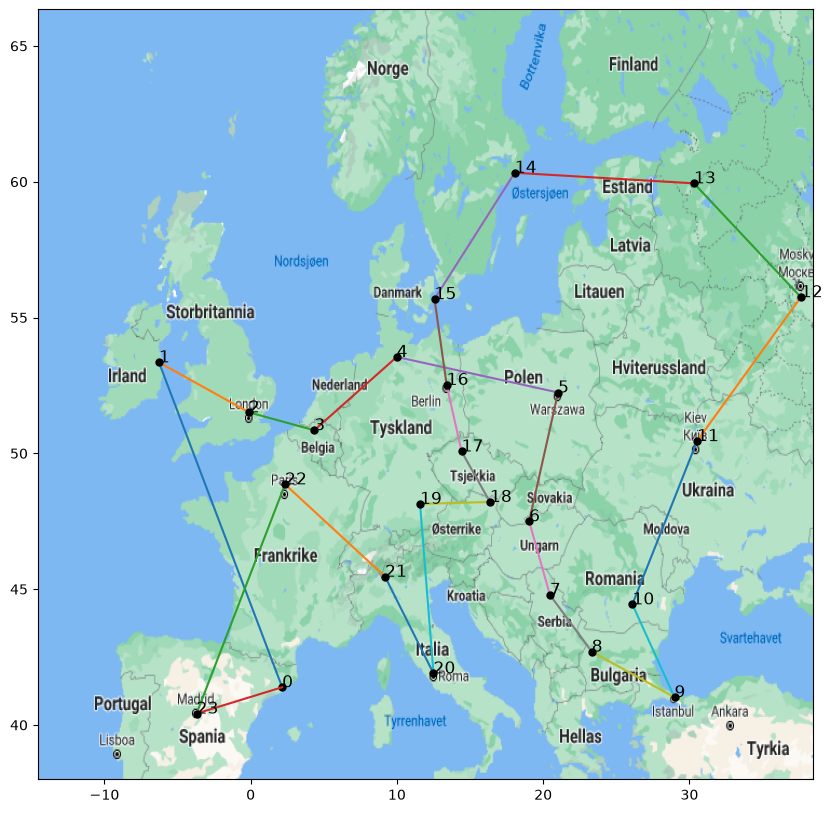

Best length: 12325.93
Best order: [ 0 18 13 15 17 23 22  5  1 20  9  4 10 14 19 21  6  2  8  3 16 11  7 12]


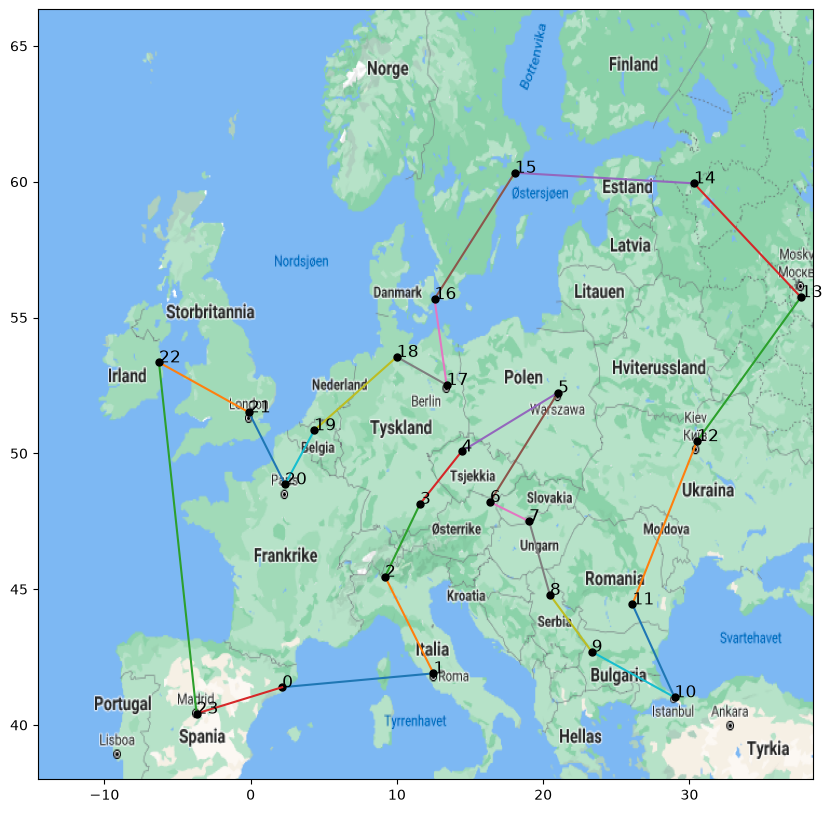

Best length: 12384.219999999996
Best order: [ 0 18 13 15 17  2 23 22  5  1 20  9  4 10 14 19 21  6  8  3 11  7 16 12]


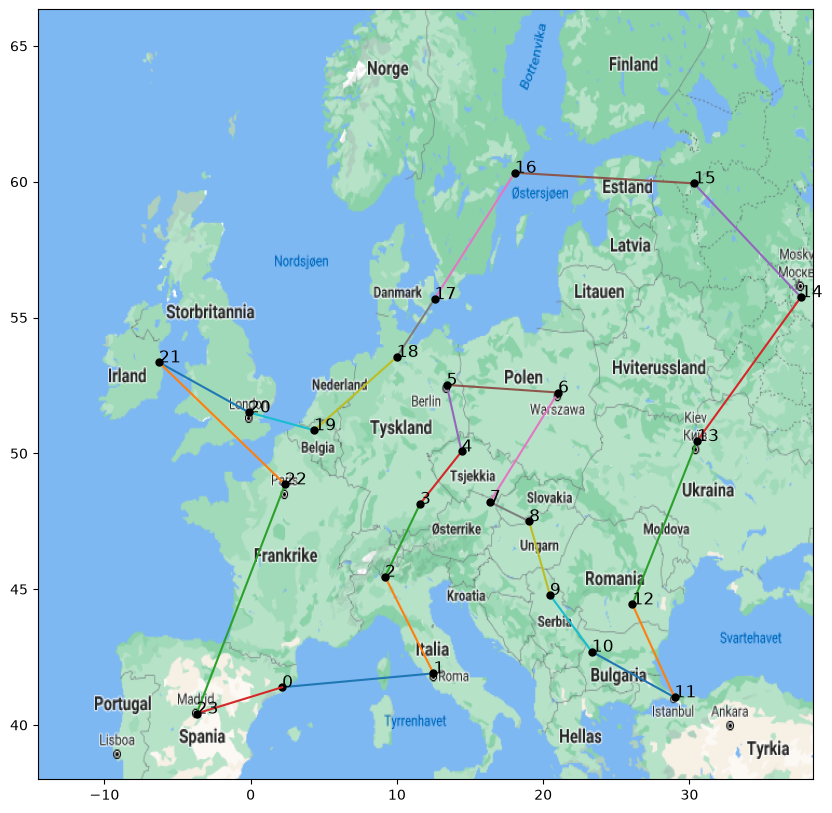

In [ ]:
best_run_20 = np.argmin(lengths_20)
best_run_50 = np.argmin(lengths_50)
best_run_100 = np.argmin(lengths_100)

#Population 20
best_order_20 = orders_20[best_run_20]

print("Best length:", lengths_20[best_run_20])
print("Best order:", best_order_20)

best_cities_20 = [cities[i] for i in best_order_20]
plot_plan(best_cities_20)

#Population 50

best_order_50 = orders_50[best_run_50]
print("Best length:", lengths_50[best_run_50])
print("Best order:", best_order_50)

best_cities_50 = [cities[i] for i in best_order_50]
plot_plan(best_cities_50)

#Population 100
best_order_100 = orders_100[best_run_100]

print("Best length:", lengths_100[best_run_100])
print("Best order:", best_order_100)

best_cities_100 = [cities[i] for i in best_order_100]
plot_plan(best_cities_100)

#Conclusion
#For population size 20, the best tour length was 13586.789999999997
#For population size 50, the best tour length was 12325.93
#For population size 100, the best tour length was 12384.219999999996
#Population size 50 found the shortest tour among the three

In [62]:
# Compare GA with exhaustive search for 10 and 24 cities

population_sizes = [20, 50, 100]
generations = 200
n_runs = 20
ga_results = {}

for n_cities in [10, 24]:
    print("\n", n_cities, "cities")

    for population_size in population_sizes:
        lengths = []
        running_times = []

        for run in range(n_runs):
            start_time = time.perf_counter()
            best_order, best_length, history = run_evolutionary_algorithm( n_cities, population_size, generations, seed=run )
            end_time = time.perf_counter()
            lengths.append(best_length)
            running_times.append(end_time - start_time)

        ga_results[(n_cities, population_size)] = { "best": np.min(lengths), "mean": np.mean(lengths), "time": np.mean(running_times) }

        print("Population size =", population_size)
        print("Best length:", np.min(lengths))
        print("Mean length:", np.mean(lengths))
        print("Mean running time:", np.mean(running_times), "seconds")




 10 cities
Population size = 20
Best length: 7486.3099999999995
Mean length: 7728.5
Mean running time: 0.1797532549884636 seconds
Population size = 50
Best length: 7486.3099999999995
Mean length: 7617.236
Mean running time: 0.4615314949885942 seconds
Population size = 100
Best length: 7486.3099999999995
Mean length: 7488.828499999999
Mean running time: 0.9477805600035936 seconds

 24 cities
Population size = 20
Best length: 13586.789999999997
Mean length: 15079.544499999998
Mean running time: 0.3146699949982576 seconds
Population size = 50
Best length: 12325.93
Mean length: 14142.932
Mean running time: 0.7684495299938134 seconds
Population size = 100
Best length: 12384.219999999996
Mean length: 14116.127499999999
Mean running time: 1.5155207849864383 seconds


In [ ]:
print("\nRunning time comparison")

for population_size in population_sizes:
    ga_time_10 = ga_results[(10, population_size)]["time"]
    ga_time_24 = ga_results[(24, population_size)]["time"]

    print("\nPopulation size =", population_size)
    print("10 cities:")
    print("GA:", ga_time_10, "seconds")
    print("Exhaustive:", time_10, "seconds")
    print("24 cities:")
    print("GA:", ga_time_24, "seconds")
    print("Estimated exhaustive:", estimated_years_24, "years")

#Conclusion

#For 10 cities, the GA found the same shortest tour as exhaustive search.
#The best length was 7486.3099999999995
#For 24 cities, the GA only took around 0.3146699949982576 to 1.5155207849864383  seconds,
#while exhaustive search was estimated to take about 1.34 billion years.
#The GA becomes slower when the population size is larger,
#but larger populations can also find better tours.


Running time comparison

Population size = 20
10 cities:
GA: 0.1797532549884636 seconds
Exhaustive: 0.593574299942702 seconds
24 cities:
GA: 0.3146699949982576 seconds
Estimated exhaustive: 1339992962.3916924 years

Population size = 50
10 cities:
GA: 0.4615314949885942 seconds
Exhaustive: 0.593574299942702 seconds
24 cities:
GA: 0.7684495299938134 seconds
Estimated exhaustive: 1339992962.3916924 years

Population size = 100
10 cities:
GA: 0.9477805600035936 seconds
Exhaustive: 0.593574299942702 seconds
24 cities:
GA: 1.5155207849864383 seconds
Estimated exhaustive: 1339992962.3916924 years


## Hybrid Algorithm (IN4050 only)
### Lamarckian
Lamarck, 1809: Traits acquired in parents’ lifetimes can be inherited by offspring. In general the algorithms are referred to as Lamarckian if the result of the local search stage replaces the individual in the population.
### Baldwinian
Baldwin effect suggests a mechanism whereby evolutionary progress can be guided towards favourable adaptation without the changes in individual's fitness arising from learning or development being reflected in changed genetic characteristics. In general the algorithms are referred to as Baldwinian if the original member is kept, but has as its fitness the value belonging to the outcome of the local search process.


(See chapter 10 and 10.2.1 from Eiben and Smith textbook for more details.)

### Task
Implement a hybrid algorithm to solve the TSP: Couple your GA and hill climber by running the hill climber a number of iterations on each individual in the population as part of the evaluation. Test both Lamarckian and Baldwinian learning models and report the results of both variants in the same way as with the pure GA (min,
max, mean and standard deviation of the end result and an averaged generational plot). How do the results compare to that of the pure GA, considering the number of evaluations done?

Lamarckian
Best length: 13377.920000000002
Evaluations: 2032000
Baldwinian
Best length: 14017.840000000002
Evaluations: 2032000
Lamarckian
Best: 12334.349999999999
Worst: 13651.859999999997
Mean: 12936.573
Standard deviation: 367.116258113149
Mean evaluations: 2032000.0
Baldwinian
Best: 13089.579999999998
Worst: 15782.629999999997
Mean: 14221.9915
Standard deviation: 757.0133185504402
Mean evaluations: 2032000.0


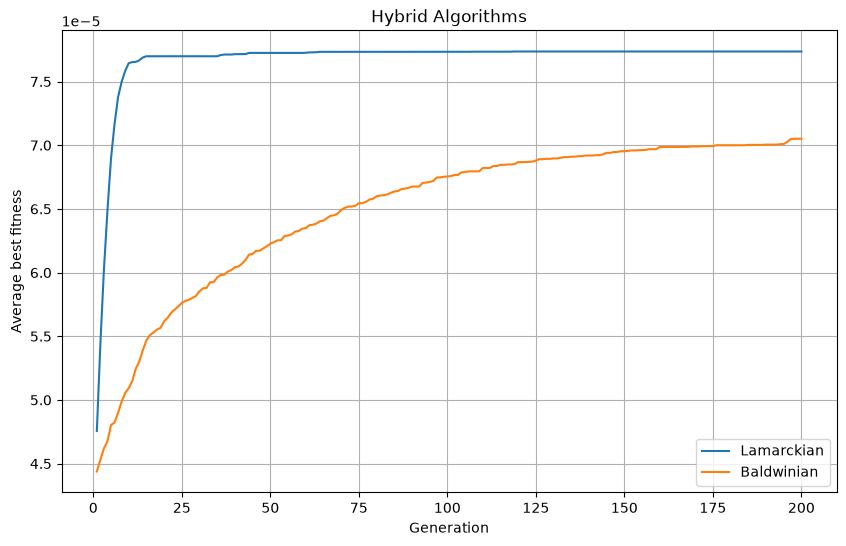

In [ ]:
# Implement algorithm here
def hill_climb_hybrid(start_order, n_cities, max_steps):
    best_order = np.array(start_order).copy()
    best_length = tour_length(best_order)
    evaluations = 1
    for _ in range(max_steps):
        candidates = []
        for i in range(1, n_cities):
            for j in range(i + 1, n_cities):
                candidate = best_order.copy()
                candidate[i], candidate[j] = candidate[j], candidate[i]
                candidates.append(candidate)
        candidate_lengths = [tour_length(candidate) for candidate in candidates]
        evaluations += len(candidates)
        best_index = np.argmin(candidate_lengths)
        new_order = candidates[best_index]
        new_length = candidate_lengths[best_index]
        if new_length < best_length:
            best_order = new_order
            best_length = new_length
        else:
            break
    return best_order, best_length, evaluations


def hybrid_evaluate_population(population, n_cities, local_search_steps, mode):
    evaluated_population = []
    learned_population = []
    fitness = []
    total_evaluations = 0
    for individual in population:
        improved_order, improved_length, evaluations = hill_climb_hybrid(individual, n_cities, local_search_steps)
        total_evaluations += evaluations
        fitness.append(1.0 / improved_length)
        learned_population.append(improved_order.copy())
        if mode == "lamarckian":
            evaluated_population.append(improved_order.copy())
        elif mode == "baldwinian":
            evaluated_population.append(individual.copy())
        else:
            raise ValueError("mode must be 'lamarckian' or 'baldwinian'")
    return np.array(evaluated_population), np.array(fitness), np.array(learned_population), total_evaluations


#Hybrid Survivor Selection

def hybrid_survivor_selection(population, fitness, learned_population, offspring, offspring_fitness, learned_offspring, population_size):
    combined_population = np.vstack((population, offspring))
    combined_fitness = np.concatenate((fitness, offspring_fitness))
    combined_learned = np.vstack((learned_population, learned_offspring))
    best_indices = np.argsort(combined_fitness)[-population_size:]
    new_population = combined_population[best_indices]
    new_fitness = combined_fitness[best_indices]
    new_learned = combined_learned[best_indices]
    return new_population, new_fitness, new_learned


def run_hybrid_algorithm(n_cities, population_size, generations, seed, local_search_steps, mode):
    rng = np.random.default_rng(seed)
    #Initialization
    population = []
    for _ in range(population_size):
        individual = np.concatenate(([0], rng.permutation(np.arange(1, n_cities))))
        population.append(individual)
    population = np.array(population)
    best_fitness_history = []
    total_evaluations = 0

    #Evolution
    for _ in range(generations):
        #Local search on current population
        population, fitness, learned_population, evaluations = hybrid_evaluate_population(population, n_cities, local_search_steps, mode)
        total_evaluations += evaluations

        #Produce offspring
        offspring = []
        while len(offspring) < population_size:
            parent_a = parent_selection(population, fitness, rng, tournament_size=3)
            parent_b = parent_selection(population, fitness, rng, tournament_size=3)
            child = crossover(parent_a, parent_b, rng)
            child = mutation(child, rng)
            offspring.append(child)

        offspring = np.array(offspring)

        #Local search on offspring
        offspring, offspring_fitness, learned_offspring, evaluations = hybrid_evaluate_population(offspring, n_cities, local_search_steps, mode)
        total_evaluations += evaluations
        #Survivor selection
        population, fitness, learned_population = hybrid_survivor_selection(population, fitness, learned_population, offspring, offspring_fitness, learned_offspring, population_size)

        #Best fitness of this generation
        best_fitness_history.append(np.max(fitness))

    #Best individual
    best_index = np.argmax(fitness)
    best_order = learned_population[best_index].copy()
    best_length = tour_length(best_order)
    return best_order, best_length, np.array(best_fitness_history), total_evaluations

n_cities = 24
population_size = 20
generations = 200
local_search_steps = 1
n_runs = 20

#Lamarckian
best_order, best_length, history, evaluations = run_hybrid_algorithm(n_cities=24, population_size=20, generations=200, seed=0, local_search_steps=1, mode="lamarckian")
print("Lamarckian")
print("Best length:", best_length)
print("Evaluations:", evaluations)

#Baldwinian
best_order, best_length, history, evaluations = run_hybrid_algorithm(n_cities=24, population_size=20, generations=200, seed=0, local_search_steps=1, mode="baldwinian")
print("Baldwinian")
print("Best length:", best_length)
print("Evaluations:", evaluations)

#Lamarckian 20 runs
lamarckian_lengths = []
lamarckian_histories = []
lamarckian_evaluations = []

for run in range(n_runs):
    best_order, best_length, history, evaluations = run_hybrid_algorithm(n_cities=24, population_size=20, generations=200, seed=run, local_search_steps=1, mode="lamarckian")
    lamarckian_lengths.append(best_length)
    lamarckian_histories.append(history)
    lamarckian_evaluations.append(evaluations)
print("Lamarckian")
report_runs(lamarckian_lengths)
print("Mean evaluations:", np.mean(lamarckian_evaluations))


#Baldwinian 20 runs
baldwinian_lengths = []
baldwinian_histories = []
baldwinian_evaluations = []

for run in range(n_runs):
    best_order, best_length, history, evaluations = run_hybrid_algorithm(n_cities=24, population_size=20, generations=200, seed=run, local_search_steps=1, mode="baldwinian")
    baldwinian_lengths.append(best_length)
    baldwinian_histories.append(history)
    baldwinian_evaluations.append(evaluations)
print("Baldwinian")
report_runs(baldwinian_lengths)
print("Mean evaluations:", np.mean(baldwinian_evaluations))

#Averaged generational plot

lamarckian_histories = np.array(lamarckian_histories)
baldwinian_histories = np.array(baldwinian_histories)
average_lamarckian = np.mean(lamarckian_histories, axis=0)
average_baldwinian = np.mean(baldwinian_histories, axis=0)
generation_axis = np.arange(1, generations + 1)
plt.figure(figsize=(10, 6))
plt.plot(generation_axis, average_lamarckian, label="Lamarckian")
plt.plot(generation_axis, average_baldwinian, label="Baldwinian")
plt.xlabel("Generation")
plt.ylabel("Average best fitness")
plt.title("Hybrid Algorithms")
plt.legend()
plt.grid()
plt.show()


# Conclusion
# For the Lamarckian, the best length is 13377.920000000002 and the number of evaluations is 2032000
# For the Baldwinian, the best length is 14017.840000000002  and the number of evaluations is 2032000
#Both methods use about 2032000 evaluations.
#The Lamarckian gives shorter tours and converges faster than the Baldwinian